<a href="https://colab.research.google.com/github/nicholas-schwier-class/Stats-Sum-26/blob/main/Class_14_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import boxcox

In [54]:
np.random.seed(42)

In [55]:
normal = np.random.normal(
    loc=50,
    scale=10,
    size=1000
)

print(normal[:10])

[54.96714153 48.61735699 56.47688538 65.23029856 47.65846625 47.65863043
 65.79212816 57.67434729 45.30525614 55.42560044]


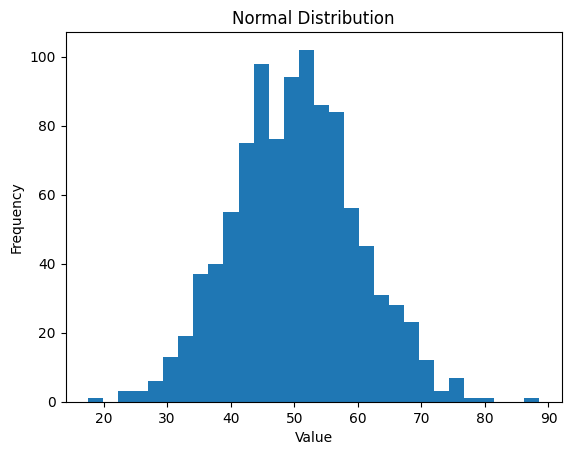

In [56]:
plt.hist(normal, bins=30)

plt.title("Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [57]:
#GENERATING SKEWED DATA
income = np.random.lognormal(
    mean=10,
    sigma=0.8,
    size=1000
)

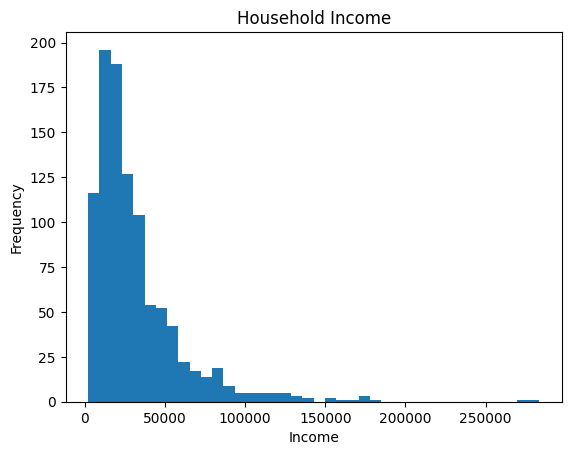

In [58]:
plt.hist(income, bins=40)

plt.title("Household Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

Measuring Skewness

Interpretation

Near 0 → symmetric

Positive → right skew

Negative → left skew

In [59]:
print(stats.skew(income))

2.9033541014201942


In [60]:
if stats.skew(income) > 1:
    print("Highly skewed")

Highly skewed


The Log Transformation

Formula

Y=log(X)

Purpose

Compresses very large values
Reduces right skew
Stabilizes variance

In [61]:
log_income = np.log(income)

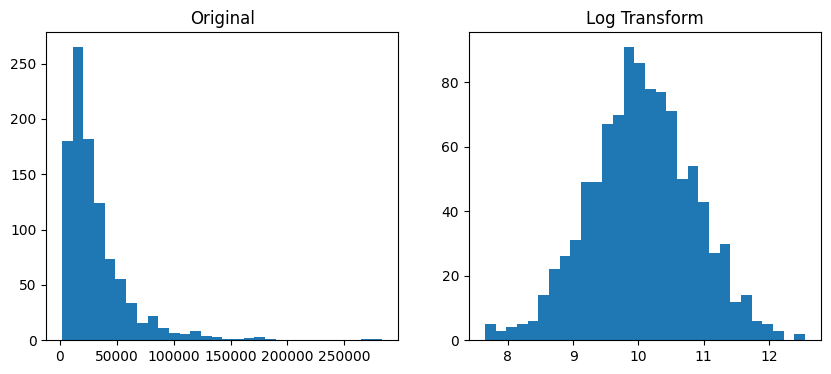

In [62]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(income,bins=30)
plt.title("Original")

plt.subplot(1,2,2)
plt.hist(log_income,bins=30)
plt.title("Log Transform")

plt.show()

Square Root Transformation

Useful for

Count data
Biological measurements
Event frequencies

Python

In [63]:
counts = np.random.poisson(
    lam=25,
    size=1000
)

sqrt_counts = np.sqrt(counts)

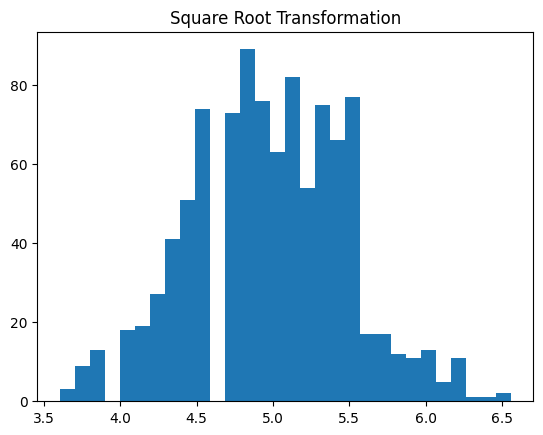

In [64]:
plt.hist(sqrt_counts,bins=30)

plt.title("Square Root Transformation")
plt.show()

Reciprocal Transformation

Formula

Y=
X
1
	​


Useful when

Extremely large observations dominate
Relationships are nonlinear

In [65]:
reciprocal = 1/income

Standardization

Many machine learning algorithms require standardized data.

Formula

Z=
σ
x−μ
	​


In [66]:
z = stats.zscore(normal)

print(z.mean())
print(z.std())

-1.056932319443149e-16
1.0


Why Standardize?

Advantages

Removes units
Easier comparison
Faster machine learning convergence
Required for PCA
Required for many clustering methods

In [67]:
scores = np.array(
    [65,72,80,90,85,75,78,92]
)

z_scores = stats.zscore(scores)

print(z_scores)

[-1.70898553 -0.89100955  0.04382014  1.21235725  0.6280887  -0.54044841
 -0.18988728  1.44606468]


Min-Max Scaling

Formula

X
′
=
max−min
x−min
	​


In [68]:
minimum = normal.min()
maximum = normal.max()

scaled = (normal-minimum)/(maximum-minimum)

Box-Cox Transformation

Automatically searches for the best power transformation.

Requirements

Positive values only

In [69]:
transformed, lam = boxcox(income)

print(lam)

0.020241929405997682


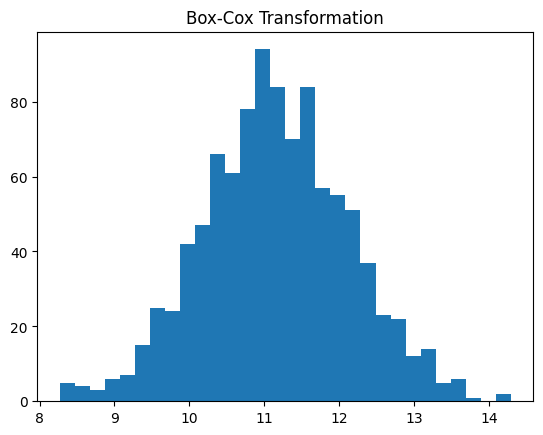

In [70]:
plt.hist(transformed,bins=30)

plt.title("Box-Cox Transformation")
plt.show()

In [71]:
print("Original")

print(stats.skew(income))

print("Log")

print(stats.skew(log_income))

print("Box-Cox")

print(stats.skew(transformed))

Original
2.9033541014201942
Log
-0.0493217739652945
Box-Cox
0.00023671602403412036


Calculating Expected Value in Python

In [72]:
import numpy as np

outcomes = np.array([0,10,25])
probabilities = np.array([0.5,0.3,0.2])

expected_value = np.sum(outcomes * probabilities)

print(expected_value)

8.0


Expected value becomes more accurate as the number of trials increases.

In [73]:
import numpy as np

outcomes = [0,10,25]
probabilities = [0.5,0.3,0.2]

simulated = np.random.choice(
    outcomes,
    size=100000,
    p=probabilities
)

print("Simulated Mean:", simulated.mean())

Simulated Mean: 7.9958


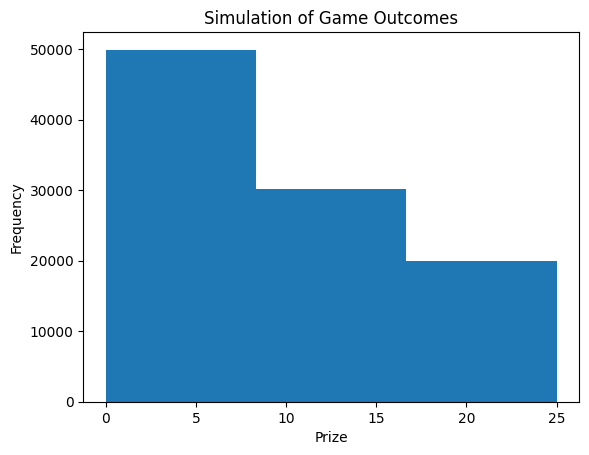

In [74]:
import matplotlib.pyplot as plt

plt.hist(simulated, bins=3)

plt.title("Simulation of Game Outcomes")
plt.xlabel("Prize")
plt.ylabel("Frequency")
plt.show()

Bayes' Theorem Example in Python

Suppose

Disease prevalence = 2%

Test sensitivity = 95%

Test specificity = 90%

In [75]:
prevalence = 0.02
sensitivity = 0.95
specificity = 0.90

false_positive = 1 - specificity

positive = (
    sensitivity * prevalence +
    false_positive * (1 - prevalence)
)

posterior = (
    sensitivity * prevalence
) / positive

print("Probability of disease given positive test:")
print(round(posterior,3))

Probability of disease given positive test:
0.162


Comparing Statistical Transformations
Objective

Learn how different statistical transformations affect skewed data and improve normality.

Scenario

A retail company has collected annual customer spending data. The distribution is highly right-skewed because a small number of customers spend much more than the average.

Tasks

Generate a lognormal dataset with 2,000 observations.

Calculate the mean, median, standard deviation, and skewness of the original data.

Apply the following transformations:

Log transformation

Square root transformation

Box-Cox transformation

Calculate the skewness after each transformation.

Create separate histograms for:

Original data

Log transformed data

Square root transformed data

Box-Cox transformed data

Perform a Shapiro-Wilk normality test for each transformed dataset.

Determine which transformation produces the distribution closest to normal.

Bayes' Theorem and Medical Testing Simulation
Objective

Use Bayes' Theorem and Monte Carlo simulation to estimate the probability that a patient actually has a disease after receiving a positive test result.

Scenario

A disease affects 1% of the population.

A medical test has

Sensitivity = 97%

Specificity = 94%

Tasks

Part A – Analytical Solution

Calculate the false positive rate.

Use Bayes' Theorem to calculate

P(Disease∣Positive)

Display the posterior probability.

Part B – Simulation

Simulate 1,000,000 patients.

Randomly assign disease status using the disease prevalence.

Simulate test results using the sensitivity and specificity.

Estimate the posterior probability using the simulated data.

Compare the simulated posterior with the analytical result.

Part C – Visualization

Create the following graphs:

Bar chart showing the number of:

True positives

False positives

True negatives

False negatives

Histogram showing simulated test outcomes

A comparison chart of analytical vs. simulated posterior probabilities